In [1]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)


In [2]:
from sklearn.model_selection import train_test_split

import pandas as pd

df = pd.read_csv("../../data/raw/teleco_churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [4]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [5]:
X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [6]:
print(X.shape)
print(y.shape)

(7043, 13601)
(7043,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 13601)
(1409, 13601)
(5634,)
(1409,)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [10]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [11]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 13601)
(1409, 13601)


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

In [13]:
lr.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
lr_pred = lr.predict(
    X_test_scaled
)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(accuracy)

0.7636621717530163


In [16]:
dir()

['In',
 'LogisticRegression',
 'Out',
 'StandardScaler',
 'X',
 'X_test',
 'X_test_scaled',
 'X_train',
 'X_train_scaled',
 '_',
 '_13',
 '_2',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy',
 'accuracy_score',
 'df',
 'df_encoded',
 'exit',
 'get_ipython',
 'lr',
 'lr_pred',
 'open',
 'pd',
 'quit',
 'scaler',
 'train_test_split',
 'y',
 'y_test',
 'y_train']

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)


In [18]:
dt.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
dt_pred = dt.predict(
    X_test
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [21]:
rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
%pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
# MODAL COMPARSION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [24]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):
    return {
        "Model":model_name,
        "Accuracy":accuracy_score(
            y_true,
            y_pred
        ),
        "Precision":precision_score(
            y_true,
            y_pred
        ),
        "Recall":recall_score(
            y_true,
            y_pred
        ),
        "F1":f1_score(
            y_true,
            y_pred
        )
    }

In [25]:
rf_pred = rf.predict(
	X_test
)

results = pd.DataFrame([
	evaluate_model(
		y_test,
		lr_pred,
		"Logistic Regression"
	),
	evaluate_model(
		y_test,
		dt_pred,
		"Decision Tree"
	),
	evaluate_model(
		y_test,
		rf_pred,
		"Random Forest"
	),
	evaluate_model(
		y_test,
		xgb_pred,
		"XGBoost"
	)
])

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.763662,0.730337,0.173797,0.280778
1,Decision Tree,0.765791,0.565868,0.505348,0.533898
2,Random Forest,0.798439,0.677165,0.459893,0.547771
3,XGBoost,0.767211,0.568452,0.510695,0.538028


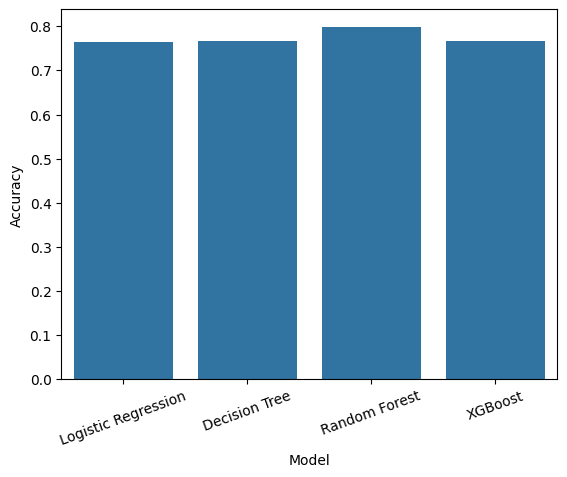

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.xticks(rotation=20)

plt.show()

In [27]:
import joblib

joblib.dump(
    lr,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [28]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [29]:
import os

print(os.listdir("../models"))

['best_model.pkl', 'best_model.pkl.bak', 'scaler.pkl', 'scaler.pkl.bak']


In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.174141
1,tenure,-0.601637
2,MonthlyCharges,0.177768
3,customerID_0003-MKNFE,-0.034916
4,customerID_0004-TLHLJ,0.000000


In [31]:
importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance.head(15)

,Feature,Coefficient
7051,InternetService_Fiber optic,0.424310
7069,PaymentMethod_Electronic check,0.410758
3506,customerID_4959-JOSRX,0.272739
7067,PaperlessBilling_Yes,0.260533
2,MonthlyCharges,0.177768
0,SeniorCitizen,0.174141
203,customerID_0318-QUUOB,0.174093
4862,customerID_6849-WLEYG,0.160522
700,customerID_1029-QFBEN,0.153876
5348,customerID_7551-JOHTI,0.147931


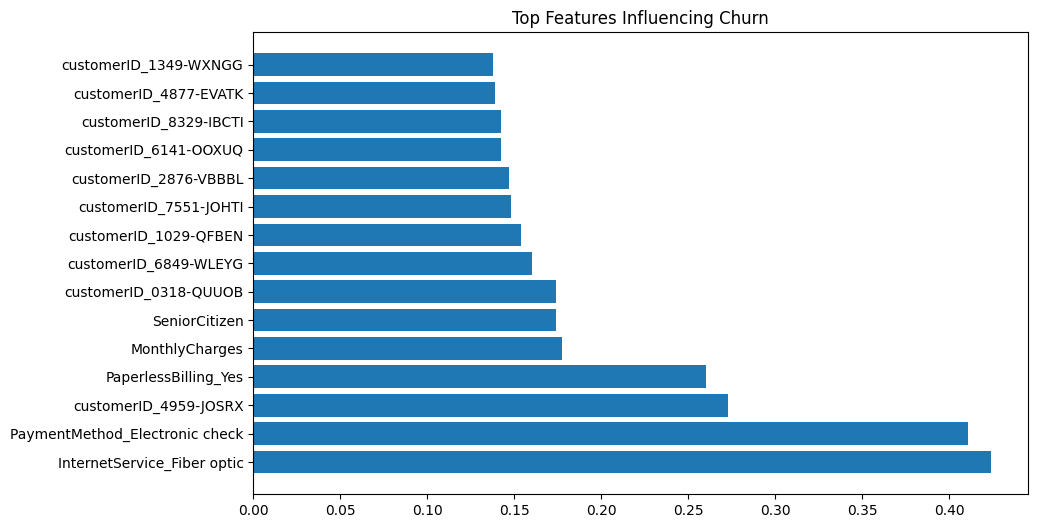

In [32]:
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Churn")

plt.show()

In [33]:


risk_scores = lr.predict_proba(
    X_test_scaled
)[:,1]



In [34]:
risk_df = pd.DataFrame({
    "RiskScore": risk_scores
})

risk_df.head()

,RiskScore
0,0.001638
1,0.233606
2,0.002482
3,0.089862
4,0.001814


In [35]:
risk_df["RiskLevel"] = pd.cut(
    risk_df["RiskScore"],
    bins=[0,0.3,0.7,1],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [36]:
risk_df["RiskLevel"].value_counts()

RiskLevel
Low       1227
Medium     145
High        37
Name: count, dtype: int64

In [37]:
# Retention Recommendation Engine

def retention_strategy(score):

    if score > 0.7:
        return "Offer Discount"

    elif score > 0.4:
        return "Personalized Call"

    else:
        return "No Action Needed"

In [40]:

risk_df["Recommendation"] = (
    risk_df["RiskScore"]
    .apply(retention_strategy)
)

risk_df.head()
display(risk_df)

,RiskScore,RiskLevel,Recommendation
0,0.001638,Low,No Action Needed
1,0.233606,Low,No Action Needed
2,0.002482,Low,No Action Needed
3,0.089862,Low,No Action Needed
4,0.001814,Low,No Action Needed
...,...,...,...
1404,0.001385,Low,No Action Needed
1405,0.000427,Low,No Action Needed
1406,0.104034,Low,No Action Needed
1407,0.000417,Low,No Action Needed
